### Logistic Regression  Exercise 

**GOAL: Create a Classification Model that can predict whether or not a person has presence of heart disease based on physical features of that person (age,sex, cholesterol, etc...)**

### dataset: heart.csv

**Complete the TASKs written in bold below.**

### Imports

**TASK: Import the necessary libraries.**

In [1]:
# Import the required libraries

import pandas as pd
import math
import sklearn
import numpy as np

# Import the visualization libraries

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Ignore warnings in Jupyter

import warnings
warnings.filterwarnings('ignore')

### Data

This database contains 14 physical attributes based on physical testing of a patient. 

Original Source: https://archive.ics.uci.edu/ml/datasets/Heart+Disease
Data set exists in the data subfolder

**TASK: Load the data into a dataframe name it df**

In [2]:
# Load the data into a dataframe, name it df
df = pd.read_csv('data/heart.csv')

In [3]:
# Display the head of the dataframe
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


### Exploratory Data Analysis and Visualization

Feel free to explore the data further on your own.

**TASK: Explore if the dataset has any missing data points and create a statistical summary of the numerical features as shown below.**

In [4]:
# Explore if the dataset has any missing data points

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [5]:
# Create a statistical summary of the numerical features

df.describe().round()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.0,303.0,303.0,303.0,303.0,303.0,303.0,303.0,303.0,303.0,303.0,303.0,303.0,303.0
mean,54.0,1.0,1.0,132.0,246.0,0.0,1.0,150.0,0.0,1.0,1.0,1.0,2.0,1.0
std,9.0,0.0,1.0,18.0,52.0,0.0,1.0,23.0,0.0,1.0,1.0,1.0,1.0,0.0
min,29.0,0.0,0.0,94.0,126.0,0.0,0.0,71.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,48.0,0.0,0.0,120.0,211.0,0.0,0.0,134.0,0.0,0.0,1.0,0.0,2.0,0.0
50%,55.0,1.0,1.0,130.0,240.0,0.0,1.0,153.0,0.0,1.0,1.0,0.0,2.0,1.0
75%,61.0,1.0,2.0,140.0,274.0,0.0,1.0,166.0,1.0,2.0,2.0,1.0,3.0,1.0
max,77.0,1.0,3.0,200.0,564.0,1.0,2.0,202.0,1.0,6.0,2.0,4.0,3.0,1.0


### Visualization Tasks

**TASK: Create a bar plot that shows the total counts per target value.**

0  45.54
1 54.46


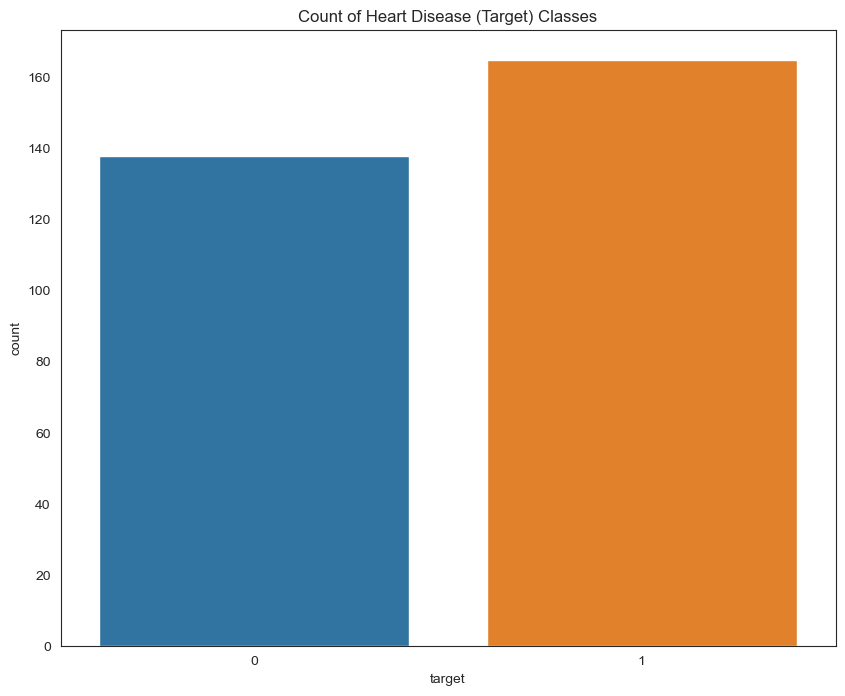

In [6]:
# Create a bar plot that shows the total counts per target value

plt.figure(figsize=(10,8))
sns.set_style('white')
sns.barplot(x=df['target'].value_counts().index,y=df['target'].value_counts())
plt.title('Count of Heart Disease (Target) Classes')
plt.ylabel('count')
plt.xlabel('target')
print ('0 ',round(df['target'].value_counts()[0]/len(df)*100,2))
print ('1',round(df['target'].value_counts()[1]/len(df)*100,2));

**TASK: Create a pairplot that displays the relationships between the following columns:**

    ['age','trestbps', 'chol','thalach','target']
   
*Note: Running a pairplot on everything can take a very long time due to the number of features*

In [7]:
# Display the columns

df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

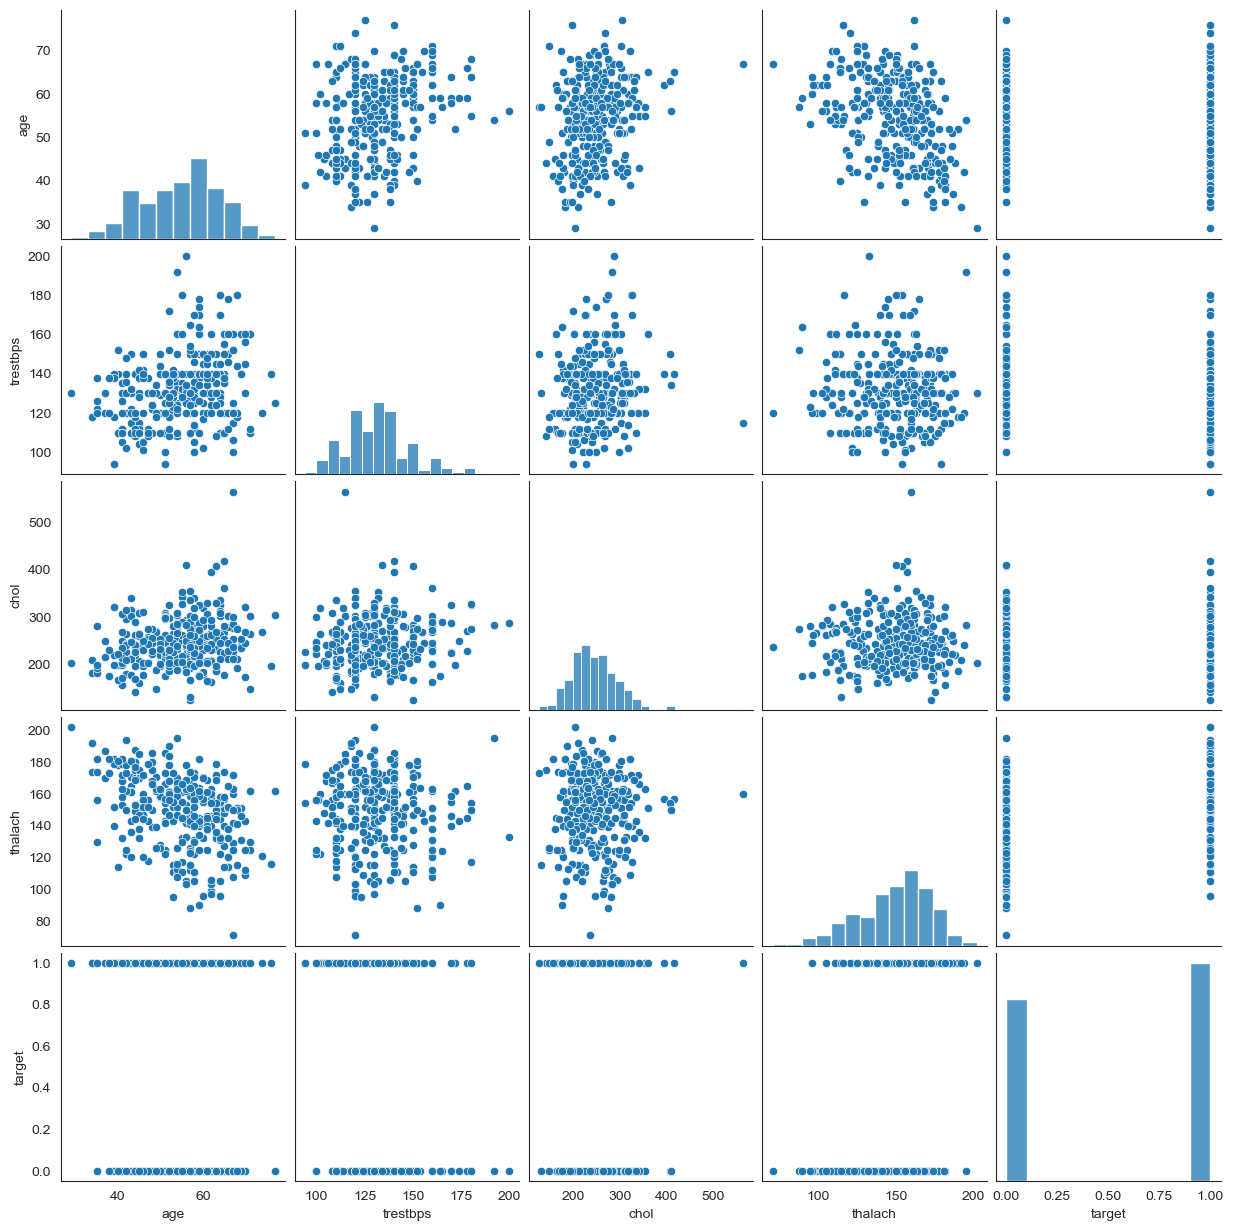

In [8]:
# Create a pairplot that displays the relationships between ['age','trestbps', 'chol','thalach','target']:

# Select the columns

df_pairplot = df[['age','trestbps','chol','thalach','target']]

# Create a pairplot for the selected columns

sns.pairplot(df_pairplot)

**TASK: Create a heatmap that displays the correlation between all the columns.**

<Axes: >

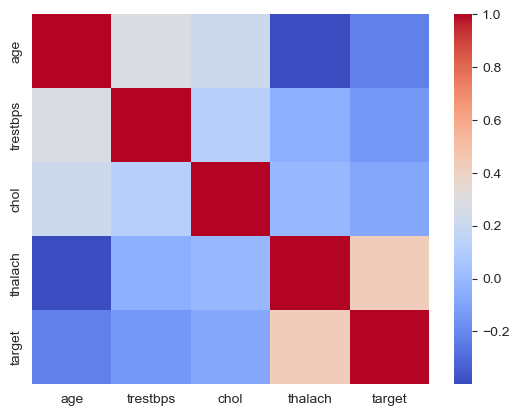

In [9]:
# Create a heatmap that displays the correlation between all the columns

#Matrix form for correlation data
df_pairplot.corr()

#Display heatmap
sns.heatmap(df_pairplot.corr(),cmap='coolwarm')

----
----

# Machine Learning

## Train Test Split and Scaling

**TASK: Separate the features from the labels into 2 objects, X and y.**

In [10]:
# Separate the features from the labels into X and y

X=df[['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal']]

y=df['target']

**TASK: Perform a train test split on the data, with the test size of 10% and a random_state of 101.**

In [11]:
# Import required libraries
# Import train_test_split
# Import StandardScaler

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [12]:
# Perform a train test split on the data, with test size of 10% and random_state of 101

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=101)

**TASK: Create a StandardScaler object and normalize the X train and test set feature data. Make sure you only fit to the training data to avoid data leakage (data knowledge leaking from the test set).**

In [13]:
# Create a StandardScaler object and call it scaler

scaler=StandardScaler()


In [14]:
# Normalize the X train and test set feature data

df_normalize=scaler.fit_transform(df)


### Coeffecients

**TASK: Report back the model's coefficients.**

In [15]:
# Import required libraries
# Import LogisticRegression

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression


In [16]:
# Create an instance of Logistic Regression 

logistic_regression = LogisticRegression()


In [17]:
# Fit the Logistic Regression model

logistic_regression.fit(X_train,y_train)


LogisticRegression()

In [18]:
# Get The model's coefficients and print the values

coefficients=logistic_regression.coef_

print("Coefficients:", coefficients)

Coefficients: [[ 0.00916299 -1.23395118  0.88004382 -0.0112659  -0.00285614 -0.01684722
   0.33720867  0.02704013 -0.73287059 -0.47899475  0.56221271 -0.80227355
  -0.87421995]]


**TASK: Create a visualization of the coefficients by using a barplot of their values. 
Figure out how to sort the plot!**

In [19]:
# Create a barplot of the coefficients
coeff_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': coefficients})
coeff_df = coeff_df.sort_values(by='Coefficient')
sns.barplot(x='Coefficient',y='Feature',data=coeff_df)
plt.title('Logistic Regression Coefficients')
plt.show()

ValueError: Per-column arrays must each be 1-dimensional

---------

## Model Performance Evaluation

**TASK: Let's now evaluate your model on the remaining 10% of the data, the test set.**

**TASK: Create the following evaluations:**
* Confusion Matrix Array
* Confusion Matrix Plot
* Classification Report

In [20]:
# Import requierd libraries: confusion_matrix, classification_report, ConfusionMatrixDisplay

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay


In [21]:
# Make predictions on the test set

y_pred=logistic_regression.predict(X_train)

In [22]:
# Create Confusion Matrix Array

cm=confusion_matrix(y_train, y_pred)

# print the Confusion Matrix values

print('Confusion Matrix:')
print(cm)

Confusion Matrix:
[[ 93  30]
 [ 12 137]]


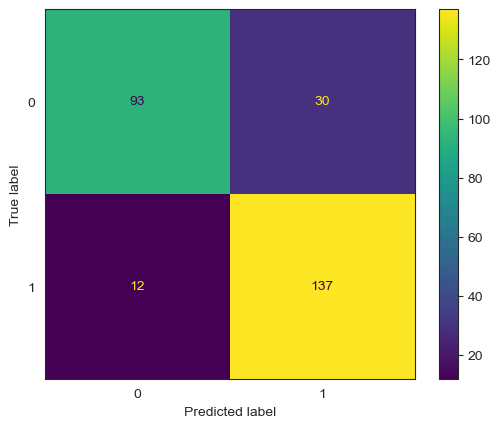

In [23]:
# Create Confusion Matrix Plot

disp=ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=logistic_regression.classes_)
disp.plot()

In [24]:
# Print  the Classification Report

print('Classification Report:\n', classification_report(y_train, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.76      0.82       123
           1       0.82      0.92      0.87       149

    accuracy                           0.85       272
   macro avg       0.85      0.84      0.84       272
weighted avg       0.85      0.85      0.84       272



### Performance Curves

**TASK: Create both the precision recall curve and the ROC Curve.**

In [25]:
# Import required libraries: precision_recall_curve, roc_curve, roc_auc_score

import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score


Text(0.5, 1.0, 'Precision-Recall curve')

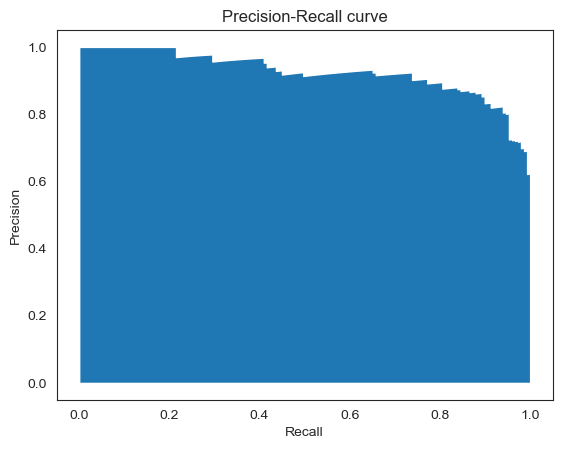

In [28]:
# Create the precision recall curve 

precision, recall, thresholds=precision_recall_curve(y_train, y_pred_proba)
plt.fill_between(recall, precision)
plt.ylabel('Precision')
plt.xlabel('Recall')
plt.title('Precision-Recall curve')

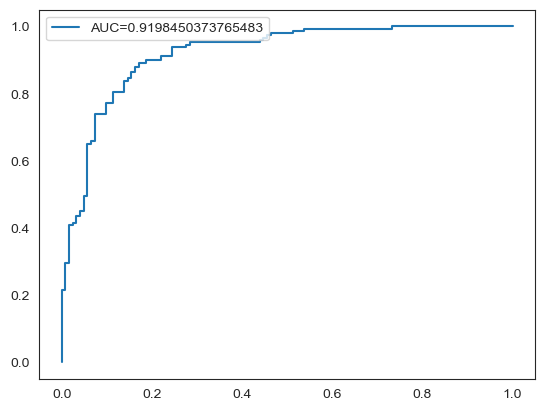

In [27]:
# Plot the ROC Curve
y_pred_proba=logistic_regression.predict_proba(X_train)[::,1]
fpr,tpr,_=metrics.roc_curve(y_train, y_pred_proba)
auc=metrics.roc_auc_score(y_train, y_pred_proba)
plt.plot(fpr,tpr,label='AUC='+str(auc))
plt.legend(loc=2)
plt.show()

**Final Task: A patient with the following features has come into the medical office:**

   

**TASK: What does your model predict for this patient? Do they have heart disease? How "sure" is your model of this prediction?**

*For convience, we created an array of the features for the patient above*

In [29]:
patient = [[ 54. ,   1. ,   0. , 122. , 286. ,   0. ,   0. , 116. ,   1. , 3.2,   1. ,   2. ,   2. ]]

In [30]:
# Predict the class for the patient

predicted=logistic_regression.predict(patient)
print(predicted)

[0]


Given the results of the prediction for the patient:
- Predicted Class: [0]
- Prediction Probability: [[0.99083015 0.00916985]]

What does the predicted class of '0' indicate about the patient's heart disease status? They are negative for heart disease.

Based on the prediction probability, how confident is the model that this patient does not have heart disease (class 0)?  Based on the prediction probability of 0.99083015 the model is extremely confident.

What is the significance of the low probability for class 1 (the presence of heart disease)?  The model is highly confident that the patient does NOT have heart disease.

Why is it important to consider both the predicted class and the prediction probability when interpreting model results?
It allows the model to capture any ambiguity in the data.

Enter your name here:  John Callahan